In [1]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.DataFrame()
     

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]
     

df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

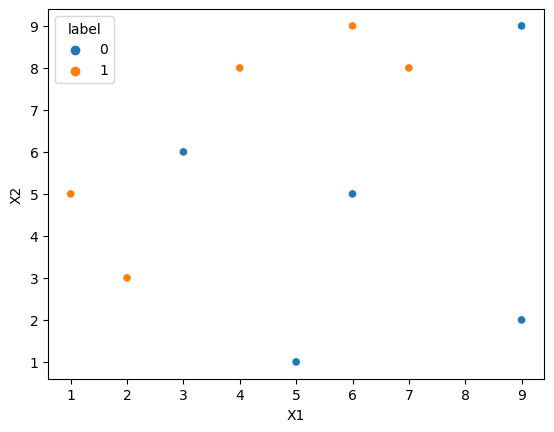

In [3]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [4]:
df['weights'] = 1/df.shape[0]

In [5]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [6]:
from sklearn.tree import DecisionTreeClassifier
     

dt1 = DecisionTreeClassifier(max_depth=1)
     

X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [7]:
# Step 2 - Train 1st model
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]')]

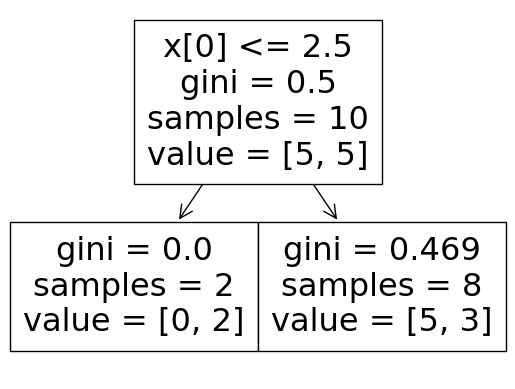

In [8]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

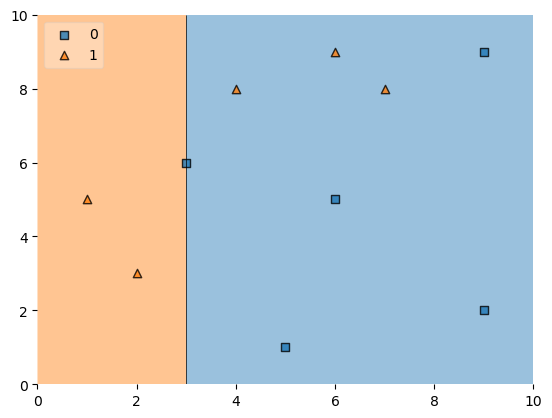

In [9]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [10]:
df['y_pred'] = dt1.predict(X)
     

df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [11]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error+0.000001))

In [12]:
#calculate alpha1
alpha1 = calculate_model_weight(0.3)
alpha1

0.42364726352971294

In [13]:
#update the weight
def update_row_weights(row,alpha=0.42364):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [14]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [15]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065466
1,2,3,1,0.1,1,0.065466
2,3,6,0,0.1,0,0.065466
3,4,8,1,0.1,0,0.152751
4,5,1,0,0.1,0,0.065466
5,6,9,1,0.1,0,0.152751
6,6,5,0,0.1,0,0.065466
7,7,8,1,0.1,0,0.152751
8,9,9,0,0.1,0,0.065466
9,9,2,0,0.1,0,0.065466


In [16]:
df['updated_weights'].sum()

0.9165151390277133

In [17]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()
     

df
    

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.065466,0.071429
1,2,3,1,0.1,1,0.065466,0.071429
2,3,6,0,0.1,0,0.065466,0.071429
3,4,8,1,0.1,0,0.152751,0.166665
4,5,1,0,0.1,0,0.065466,0.071429
5,6,9,1,0.1,0,0.152751,0.166665
6,6,5,0,0.1,0,0.065466,0.071429
7,7,8,1,0.1,0,0.152751,0.166665
8,9,9,0,0.1,0,0.065466,0.071429
9,9,2,0,0.1,0,0.065466,0.071429


In [18]:
df['nomalized_weights'].sum()

1.0

In [19]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])
     

df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [20]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065466,0.000000,0.071429
1,2,3,1,0.1,1,0.065466,0.071429,0.142858
2,3,6,0,0.1,0,0.065466,0.142858,0.214288
3,4,8,1,0.1,0,0.152751,0.214288,0.380953
4,5,1,0,0.1,0,0.065466,0.380953,0.452382
5,6,9,1,0.1,0,0.152751,0.452382,0.619047
6,6,5,0,0.1,0,0.065466,0.619047,0.690476
7,7,8,1,0.1,0,0.152751,0.690476,0.857142
8,9,9,0,0.1,0,0.065466,0.857142,0.928571
9,9,2,0,0.1,0,0.065466,0.928571,1.000000


In [21]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices
     

In [22]:
index_values = create_new_dataset(df)

In [23]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [24]:
second_df

,X1,X2,label,weights
1,2,3,1,0.1
0,1,5,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
0,1,5,1,0.1
9,9,2,0,0.1
5,6,9,1,0.1
7,7,8,1,0.1
2,3,6,0,0.1


In [25]:
dt2 = DecisionTreeClassifier(max_depth=1)
     

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values
     

dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.75, 0.25, 'gini = 0.198\nsamples = 9\nvalue = [1, 8]')]

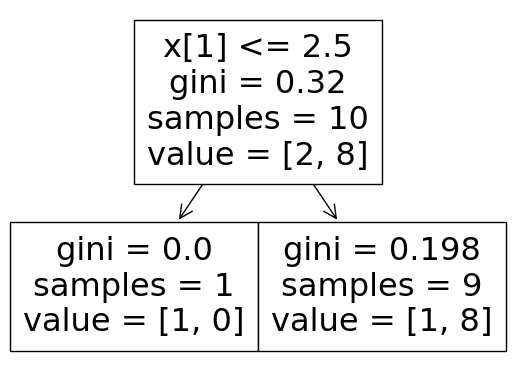

In [26]:
plot_tree(dt2)

<Axes: >

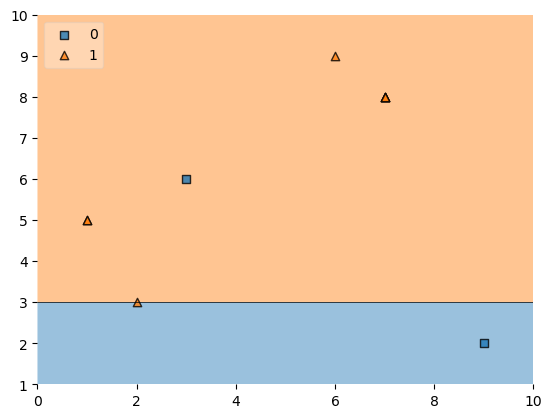

In [27]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [28]:
second_df['y_pred'] = dt2.predict(X)
     

second_df

,X1,X2,label,weights,y_pred
1,2,3,1,0.1,1
0,1,5,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
0,1,5,1,0.1,1
9,9,2,0,0.1,0
5,6,9,1,0.1,1
7,7,8,1,0.1,1
2,3,6,0,0.1,1


In [44]:
alpha2 = calculate_model_weight(0.1)
alpha2

1.0986072886931095

In [29]:
# Step 4 - Update weights
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)
     

In [30]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)
     

second_df

,X1,X2,label,weights,y_pred,updated_weights
1,2,3,1,0.1,1,0.033622
0,1,5,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
0,1,5,1,0.1,1,0.033622
9,9,2,0,0.1,0,0.033622
5,6,9,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
2,3,6,0,0.1,1,0.297427


In [31]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [32]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
1,2,3,1,0.1,1,0.033622,0.056034
0,1,5,1,0.1,1,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
0,1,5,1,0.1,1,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
5,6,9,1,0.1,1,0.033622,0.056034
7,7,8,1,0.1,1,0.033622,0.056034
2,3,6,0,0.1,1,0.297427,0.495694


In [33]:
second_df['nomalized_weights'].sum()

1.0

In [35]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [36]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
1,2,3,1,0.1,1,0.056034,0.000000,0.056034
0,1,5,1,0.1,1,0.056034,0.056034,0.112068
7,7,8,1,0.1,1,0.056034,0.112068,0.168102
7,7,8,1,0.1,1,0.056034,0.168102,0.224136
7,7,8,1,0.1,1,0.056034,0.224136,0.280170
0,1,5,1,0.1,1,0.056034,0.280170,0.336204
9,9,2,0,0.1,0,0.056034,0.336204,0.392238
5,6,9,1,0.1,1,0.056034,0.392238,0.448272
7,7,8,1,0.1,1,0.056034,0.448272,0.504306
2,3,6,0,0.1,1,0.495694,0.504306,1.000000


In [37]:
index_values = create_new_dataset(second_df)
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [38]:
third_df

,X1,X2,label,weights
5,6,9,1,0.1
0,1,5,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
0,1,5,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1


In [39]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

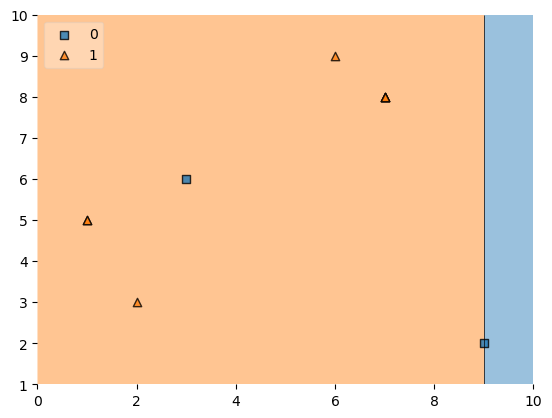

In [40]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [41]:
third_df['y_pred'] = dt3.predict(X)

third_df

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,1
0,1,5,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
5,6,9,1,0.1,0
0,1,5,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1


In [42]:
alpha3 = calculate_model_weight(0.7)
alpha3

-0.42364964447880576

In [45]:
print(alpha1,alpha2,alpha3)

0.42364726352971294 1.0986072886931095 -0.42364964447880576


### Prediction

In [46]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1], dtype=int64)

In [47]:
dt2.predict(query)

array([1], dtype=int64)

In [48]:
dt3.predict(query)

array([1], dtype=int64)

In [49]:
alpha1*1 + alpha2*(1) + alpha3*(1)

1.0986049077440165

In [50]:
np.sign(1.09)

1.0